# Ablation Experiments Setup and Tests

## Setup and Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from src.hmm import HMM, Mess3Proc
from src.model import HookedTransformerModel
from tqdm import tqdm
from scipy.special import logsumexp
import numpy as np
import pandas as pd
import os
import itertools
from collections import Counter
import torch as t
import matplotlib.pyplot as plt

## Define the HMM and Load Models

Get Models with context length 15

In [3]:
# Testing important directions in the model
# generate test sequences
proc = Mess3Proc()
# test_sequences = proc.generate_data(20, 5000)

# Look for model instances
metadata_path = '/mnt/extraspace/clin/records/metadata.parquet'
df = pd.read_parquet(metadata_path)
df_completed = df[df['status'] == 'completed']

df_15 = df_completed[df_completed['n_ctx'] == 15]
df_15 = df_15.sort_values(by='final_val_loss', ascending=True) 

# df_selected = df_completed.loc[selected_locs]
# print(df_selected[['final_val_loss', 'param_count', 'n_ctx']])

In [4]:
# model_dir_path = df.loc[20]['run_dir'] 
model_dir_path = df_15.iloc[1]['run_dir']
def load_model(model_dir_path, device='cpu'):
    model = HookedTransformerModel(os.path.join(model_dir_path, 'config.yaml'))
    model.load_state_dict(t.load(os.path.join(model_dir_path, 'final_model_mess3.pt'), map_location=device))
    model.eval()
    return model
model = load_model(model_dir_path)

## PCA and extraction of informative directions

Instability observed: for ctx 15 it seems the direct PCA has worse R2 square than what's been saved.

In [171]:
# extract the regressor
import pickle
# for different layers
layer = 0
regressors = pickle.load(open(os.path.join('/mnt/extraspace/clin', model_dir_path, 'regressors.pkl'), 'rb'))
reg = regressors[layer]

### Test that MSE is as expected

In [175]:
print(f"Context length: {model.model.cfg.n_ctx}")
test_seq = proc.generate_data(1000, model.model.cfg.n_ctx, init_state=None)

# ============ USING PYTORCH HOOKS (STANDARD APPROACH) ============
# This is the standard ML practice for extracting intermediate activations

# Dictionary to store activations
activations = {}

def get_activation(name):
    """
    Returns a hook function that saves the output of a layer.
    This is a closure - it "closes over" the name variable.
    """
    def hook(module, input, output):
        activations[name] = output.detach()  # detach to save memory
    return hook

# Register hooks on the layers you want to capture
# You can register multiple hooks to capture from multiple layers at once
hook_handles = []
hook_handles.append(model.model.blocks[layer].register_forward_hook(
    get_activation(f'block_{layer}')
))

# Now just run a normal forward pass - hooks will automatically capture activations
model.eval()
with t.no_grad():
    logits = model(test_seq)  # This runs the full forward pass
    # Activations are now stored in the 'activations' dictionary

# Clean up hooks when done (important!)
for handle in hook_handles:
    handle.remove()

# Extract the residual activation you want
resid = activations[f'block_{layer}']

# ============ REST OF YOUR CODE ============
X = resid[:, -6, :]
Y = reg.predict(X)

belief_state = proc.mixed_state_presentation(test_seq)
y = belief_state[:, -6, :]
print(f"R² score: {reg.score(X, y)}")
mse = np.mean((Y - y)**2)

print(f"MSE: {mse}")

Context length: 15
R² score: 0.9977002067826928
MSE: 0.00037636882647833474


In [173]:
pca_data = pd.read_csv(os.path.join('/mnt/extraspace/clin', model_dir_path, 'pca_metrics.csv'))
pca_data.head()


,layer,mse,r2_score,baseline_mse
0,0,0.000365,0.997804,0.166091
1,1,0.000155,0.999067,0.166091


## Two metrics

In order to test whether the ablated model can faithfully predict, 
1. Coarse metric: the validation loss at the level of tokens.
2. Fine metric: comparing the logits from the ground truth directly.

In [ ]:
# ============ CRITICAL COMPARISON: Hooks vs TransformerLens Cache ============
# Let's compare BOTH methods side-by-side with the SAME data

import pickle
layer = 0

# Generate test data
print(f"Context length: {model.model.cfg.n_ctx}")
test_seq = proc.generate_data(1000, model.model.cfg.n_ctx, init_state=None)

# ============ METHOD 1: PyTorch Hooks (What we just added) ============
activations_hook = {}
def get_activation(name):
    def hook(module, input, output):
        activations_hook[name] = output.detach()
    return hook

hook_handles = []
hook_handles.append(model.model.blocks[layer].register_forward_hook(
    get_activation(f'block_{layer}')
))

model.eval()
with t.no_grad():
    logits_hook = model(test_seq)

for handle in hook_handles:
    handle.remove()

resid_hook = activations_hook[f'block_{layer}']
print(f"\nMETHOD 1 (Hooks):")
print(f"  Activation shape: {resid_hook.shape}")
print(f"  Activation mean: {resid_hook.mean():.6f}, std: {resid_hook.std():.6f}")

# ============ METHOD 2: TransformerLens run_with_cache (pca.py method) ============
model.eval()
with t.no_grad():
    cache = model.model.run_with_cache(test_seq)

resid_cache = cache["resid_post", layer]
print(f"\nMETHOD 2 (TransformerLens cache):")
print(f"  Activation shape: {resid_cache.shape}")
print(f"  Activation mean: {resid_cache.mean():.6f}, std: {resid_cache.std():.6f}")

# ============ COMPARE THE TWO METHODS ============
print(f"\nCOMPARISON:")
print(f"  Logits match: {t.allclose(logits_hook, logits_cache, rtol=1e-5, atol=1e-5)}")
print(f"  Activations match: {t.allclose(resid_hook, resid_cache, rtol=1e-5, atol=1e-5)}")
print(f"  Max difference in activations: {(resid_hook - resid_cache).abs().max():.10f}")
print(f"  Mean difference in activations: {(resid_hook - resid_cache).abs().mean():.10f}")

# ============ COMPUTE R² FOR BOTH METHODS ============
reg = pickle.load(open(os.path.join('/mnt/extraspace/clin', model_dir_path, 'regressors.pkl'), 'rb'))[layer]
belief_state = proc.mixed_state_presentation(test_seq)

# Method 1 (Hooks)
X_hook = resid_hook[:, -1, :].cpu().numpy()
y = belief_state[:, -1, :]
r2_hook = reg.score(X_hook, y)
mse_hook = np.mean((reg.predict(X_hook) - y)**2)

# Method 2 (Cache)
X_cache = resid_cache[:, -1, :].cpu().numpy()
r2_cache = reg.score(X_cache, y)
mse_cache = np.mean((reg.predict(X_cache) - y)**2)

print(f"\nR² COMPARISON:")
print(f"  Method 1 (Hooks):           R² = {r2_hook:.6f}, MSE = {mse_hook:.6f}")
print(f"  Method 2 (TransformerLens): R² = {r2_cache:.6f}, MSE = {mse_cache:.6f}")
print(f"  Difference in R²:           {abs(r2_hook - r2_cache):.10f}")

Context length: 15

METHOD 1 (Hooks):
  Activation shape: torch.Size([1000, 15, 32])
  Activation mean: 0.114227, std: 4.198812

METHOD 2 (TransformerLens cache):
  Activation shape: torch.Size([1000, 15, 32])
  Activation mean: 0.114227, std: 4.198812

COMPARISON:
  Logits match: True
  Activations match: True
  Max difference in activations: 0.0000000000
  Mean difference in activations: 0.0000000000

R² COMPARISON:
  Method 1 (Hooks):           R² = 0.991172, MSE = 0.001496
  Method 2 (TransformerLens): R² = 0.991172, MSE = 0.001496
  Difference in R²:           0.0000000000


In [ ]:
# ============ EXACT REPLICATION OF pca.py METHOD ============
# This should give you the EXACT same R² as in pca_metrics.csv

layer = 0

# Generate large sample (matching pca.py's batch_size)
print("Generating 100k samples (this may take a moment)...")
test_seq_large = proc.generate_data(5000, model.model.cfg.n_ctx, init_state=None)

# Extract activations using TransformerLens's run_with_cache (EXACTLY as pca.py does)
model.eval()
with t.no_grad():
    logits, cache = model.model.run_with_cache(test_seq_large)

# Get residual stream at the specified layer
resid = cache["resid_post", layer]

# Use LAST position (matching pca.py line 148, 212)
X = resid[:, -1, :].cpu().numpy()

# Get belief states
belief_state = proc.mixed_state_presentation(test_seq_large)
y = belief_state[:, -1, :]  # Last position

# Load the regressor that was trained in pca.py
reg = pickle.load(open(os.path.join('/mnt/extraspace/clin', model_dir_path, 'regressors.pkl'), 'rb'))[layer]

# Compute metrics (exactly as pca.py does in learn_affine_mapping)
r2_score = reg.score(X, y)
predictions = reg.predict(X)
mse = np.mean((predictions - y)**2)
baseline_mse = np.mean((y - y.mean(axis=0))**2)

print(f"\n{'='*70}")
print(f"EXACT REPLICATION OF pca.py:")
print(f"{'='*70}")
print(f"Layer {layer}:")
print(f"  R² score:      {r2_score:.6f}")
print(f"  MSE:           {mse:.6f}")
print(f"  Baseline MSE:  {baseline_mse:.6f}")

# Compare with saved results
saved_metrics = pd.read_csv(os.path.join('/mnt/extraspace/clin', model_dir_path, 'pca_metrics.csv'))
saved_r2 = saved_metrics[saved_metrics['layer'] == layer]['r2_score'].values[0]
saved_mse = saved_metrics[saved_metrics['layer'] == layer]['mse'].values[0]

print(f"\n{'='*70}")
print(f"COMPARISON WITH SAVED pca_metrics.csv:")
print(f"{'='*70}")
print(f"Saved R²:       {saved_r2:.6f}")
print(f"Saved MSE:      {saved_mse:.6f}")
print(f"R² difference:  {abs(r2_score - saved_r2):.10f}")
print(f"MSE difference: {abs(mse - saved_mse):.10f}")

if abs(r2_score - saved_r2) < 1e-4:
    print("\n✓ R² matches saved results! The methods are equivalent.")
else:
    print("\n✗ R² differs from saved results. Possible reasons:")
    print("  1. Different random data (expected)")
    print("  2. Different model checkpoint was used")
    print("  3. Implementation difference")

Generating 100k samples (this may take a moment)...

EXACT REPLICATION OF pca.py:
Layer 0:
  R² score:      0.978584
  MSE:           0.003556
  Baseline MSE:  0.166059

COMPARISON WITH SAVED pca_metrics.csv:
Saved R²:       0.978372
Saved MSE:      0.003592
R² difference:  0.0002123739
MSE difference: 0.0000355732

✗ R² differs from saved results. Possible reasons:
  1. Different random data (expected)
  2. Different model checkpoint was used
  3. Implementation difference


# Experiment

## Model choice

In [ ]:
df_selected = df_completed[(df_completed['n_ctx'] < 15) & (df_completed['uuid'].notnull()) & (df_completed['uuid'] != "")]
df_selected = df_selected.sort_values(by='final_val_loss', ascending=True)

model_dir_path = df_selected.iloc[2]['run_dir']
df_selected[['run_id', 'n_ctx', 'final_val_loss', 'param_count']].head()
model = load_model(model_dir_path)

## Get Orthogonal Bases

In [1]:
import pickle
from jaxtyping import Float
layer = 1
regressors = pickle.load(open(os.path.join('/mnt/extraspace/clin', model_dir_path, 'regressors.pkl'), 'rb'))
reg = regressors[layer]
coef = reg.coef_
U, S, VT = np.linalg.svd(coef)
orth_subspace = VT[3:]
para_subspace = coef / np.linalg.norm(coef, axis=1, keepdims=True)

NameError: name 'os' is not defined

In [54]:
para_subspace.shape

(3, 32)

## Run the model with intervention

In [7]:
samples = proc.generate_data(1000, model.model.cfg.n_ctx, init_state=None)

In [18]:
from jaxtyping import Float
def ablate_direction(
    actvs: Float[t.Tensor, "batch seq_len d_model"],
    direction: Float[t.Tensor, "d_model"],
    method: str = "mean"
):
    direction = direction / direction.norm()
    actvs_para_B = actvs[:, -1, :] @ direction
    actvs_para_BM = actvs_para_B.unsqueeze(-1) * direction
    if method == "mean":
        actvs_para_mean_M = actvs_para_BM.mean(dim=0)
        actvs[:, -1, :] = actvs[:, -1, :] - actvs_para_BM + actvs_para_mean_M.unsqueeze(0)
    elif method == "zero":
        actvs[:, -1, :] = actvs[:, -1, :] - actvs_para_BM
    else:
        raise ValueError(f"Invalid method: {method}")
    return actvs


samples = t.tensor(samples)
direction = t.tensor(para_subspace[1])
random_direction = t.randn(model.model.cfg.d_model)
random_direction = random_direction / random_direction.norm()

logits_clean, cache_clean = model.model.run_with_cache(samples)
logits_clean = logits_clean[:, -1, :]
logits_mean_abl = model.model.run_with_hooks(
    samples,
    fwd_hooks=[
        (f"blocks.{layer}.hook_resid_post", lambda resid, hook: ablate_direction(resid, direction, method="mean"))
    ]
)[:, -1, :]
logits_zero_abl = model.model.run_with_hooks(
    samples,
    fwd_hooks=[
        (f"blocks.{layer}.hook_resid_post", lambda resid, hook: ablate_direction(resid, direction, method="zero"))
    ]
)[:, -1, :]

logit_mean_abl_baseline = model.model.run_with_hooks(
    samples,
    fwd_hooks=[
        (f"blocks.{layer}.hook_resid_post", lambda resid, hook: ablate_direction(resid, random_direction, method="mean"))
    ]
)[:, -1, :]
logit_zero_abl_baseline = model.model.run_with_hooks(
    samples,
    fwd_hooks=[
        (f"blocks.{layer}.hook_resid_post", lambda resid, hook: ablate_direction(resid, random_direction, method="zero"))
    ]
)[:, -1, :]


/tmp/ipykernel_4005368/3098116468.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  samples = t.tensor(samples)


In [12]:
def log_likelihood_true(hmm: HMM, sequences_np: np.ndarray, device: str = 'cuda', batch_mean: bool = True, seq_mean: bool = True, use_tqdm: bool = False) -> t.Tensor:
    batch_size, T = sequences_np.shape
    E = hmm.emission_matrices
    log_E = np.log(E)

    init_state = hmm.get_stationary_distribution()
    log_init_state = np.log(init_state)

    log_likelihoods = []
    for batch_idx in tqdm(range(batch_size), desc="Computing true log-likelihood", disable=not use_tqdm):
        seq = sequences_np[batch_idx]
        
        log_emission_0 = log_E[seq[0]]
        log_alpha = logsumexp(log_init_state[:, np.newaxis] + log_emission_0, axis=0)

        for t in range(1, T):
            log_emission_t = log_E[seq[t]]
            log_prob_xt = logsumexp(log_alpha[:, np.newaxis] + log_emission_t)
            log_alpha = logsumexp(log_alpha[:, np.newaxis] + log_emission_t, axis=0)
        
        log_likelihoods.append(logsumexp(log_alpha))

    if batch_mean:
        log_likelihoods = np.array(log_likelihoods).mean(axis=0)
    if seq_mean:
        log_likelihoods = np.array(log_likelihoods).mean(axis=1)

    return log_likelihoods

log_likelihoods = log_likelihood_true(proc, np.array(samples), batch_mean=False, seq_mean=False, device='cuda')


/tmp/ipykernel_4005368/1890738360.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  log_likelihoods = log_likelihood_true(proc, np.array(samples), batch_mean=False, seq_mean=False, device='cuda')


(array([  3.,  25.,  60., 112., 195., 200., 142., 145., 103.,  15.]),
 array([-21.69703712, -20.0255547 , -18.35407227, -16.68258985,
        -15.01110743, -13.339625  , -11.66814258,  -9.99666015,
         -8.32517773,  -6.6536953 ,  -4.98221288]),
 <BarContainer object of 10 artists>)

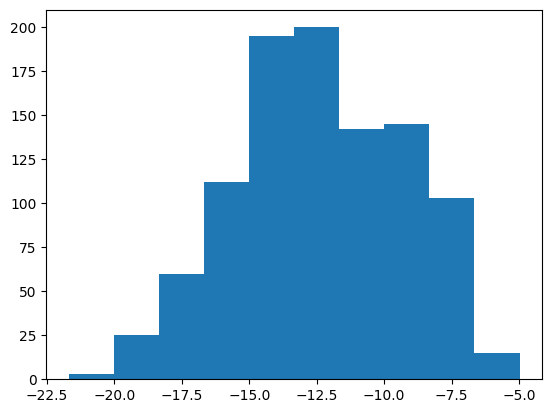

In [16]:
log_likelihoods = np.stack(log_likelihoods)
plt.hist(log_likelihoods)

In [25]:
logits_clean

tensor([[-0.3487,  1.5212, -0.3560],
        [-0.9000, -0.8843,  0.9844],
        [-0.2421, -1.2532,  0.0208],
        ...,
        [-0.3990,  1.1365, -0.1888],
        [-0.3782,  1.4938, -0.3856],
        [-0.3685,  1.5007, -0.3712]], grad_fn=<SliceBackward0>)

In [23]:
logit_mean_abl_baseline

tensor([[-0.3317,  1.5137, -0.3611],
        [-0.9020, -0.8792,  0.9831],
        [-0.2535, -1.2351,  0.0210],
        ...,
        [-0.3864,  1.1267, -0.1909],
        [-0.3606,  1.4860, -0.3915],
        [-0.3507,  1.4929, -0.3768]], grad_fn=<SliceBackward0>)

In [21]:
logits_mean_abl

tensor([[-0.1438,  1.0137, -0.2235],
        [-1.0989, -0.6037,  0.9613],
        [-0.3838, -1.0155, -0.0656],
        ...,
        [-0.2212,  0.6672, -0.0637],
        [-0.1809,  0.9977, -0.2583],
        [-0.1697,  1.0030, -0.2425]], grad_fn=<SliceBackward0>)

In [ ]:
import torch.nn.functional as F

logits_clean = F.log_softmax(logits_clean, dim=-1)
logit_mean_abl_baseline = F.log_softmax(logit_mean_abl_baseline, dim=-1)
logits_mean_abl = F.log_softmax(logits_mean_abl, dim=-1)

kl_baseline = F.kl_div(logits_clean, logit_mean_abl_baseline, reduction='none', log_target=True).sum(dim=-1)
kl_fractal_dir = F.kl_div(logits_clean, logits_mean_abl, reduction='none', log_target=True).sum(dim=-1)

import matplotlib.pyplot as plt

# Detach and move to CPU for plotting, if on GPU
kl_baseline_vals = kl_baseline.detach().cpu().numpy().flatten()
kl_fractal_dir_vals = kl_fractal_dir.detach().cpu().numpy().flatten()

print(f'mean kl divergence: for baseline: {kl_baseline_vals.mean()}, for the fractal direction: {kl_fractal_dir_vals.mean()}')


mean kl divergence: for baseline: 4.3209238356212154e-05, for fractal direction: 0.01765797846019268


## Ablation Data Analysis

Load and analyze ablation experiment results. The data contains KL divergence measurements when ablating different direction types:
- **Para (fractal)**: Directions parallel to the belief state subspace
- **Orth (non-fractal)**: Directions orthogonal to the belief state subspace  
- **Random**: Random baseline directions

In [78]:
import pickle

# Load ablation statistics
# Choose which dataset to analyze:
USE_ALL_POSITIONS = True  # True for ablation_stats_all.pkl, False for ablation_stats.pkl

if USE_ALL_POSITIONS:
    with open('data/ablation_stats_all.pkl', 'rb') as f:
        abl_stats_dict = pickle.load(f)
    print("Loaded: ablation_stats_all.pkl (ablating at all positions)")
else:
    with open('data/ablation_stats.pkl', 'rb') as f:
        abl_stats_dict = pickle.load(f)
    print("Loaded: ablation_stats.pkl (ablating at last position only)")

# Map to dataframe
dir_paths = list(abl_stats_dict.keys())
df['abl_stats'] = df['run_dir'].map(abl_stats_dict)

# Filter to models that have ablation stats
selected_columns = ['run_dir', 'abl_stats', 'n_ctx', 'n_layer', 'n_embd', 'param_count', 'final_val_loss']
df_filtered = df.loc[df['abl_stats'].notna(), selected_columns]

print(f"Found {len(df_filtered)} models with ablation statistics")

Loaded: ablation_stats_all.pkl (ablating at all positions)
Found 440 models with ablation statistics


In [79]:
def extract_kl_values(row):
    """
    Extract KL divergence values from ablation statistics.
    
    Assumes data ordering: [para (3 directions), orth (n_embd-3 directions), rand (4 directions)]
    """
    stats = row['abl_stats']
    n_embd = int(row['n_embd'])
    
    # Clip negative values (numerical precision errors near zero)
    stats = np.maximum(stats, 0)
    
    # Calculate number of directions in each group
    n_para = min(3, n_embd)          # Parallel to belief state (fractal directions)
    n_orth = max(0, n_embd - 3)      # Orthogonal to belief state (non-fractal)
    n_random = 4                      # Random baseline directions
    
    # Extract mean KL divergence for each group
    # Data format: (n_layers, n_directions, n_sequences)
    # Direction ordering: [para, orth, rand]
    kl_para = stats[:, :n_para, :].mean() if n_para > 0 else np.nan
    kl_orth = stats[:, n_para:n_para+n_orth, :].mean() if n_orth > 0 else np.nan
    kl_random = stats[:, -n_random:, :].mean()
    
    return pd.Series({'kl_para': kl_para, 'kl_orth': kl_orth, 'kl_random': kl_random})

# Apply extraction and sort by validation loss
df_filtered[['kl_para', 'kl_orth', 'kl_random']] = df_filtered.apply(extract_kl_values, axis=1)
df_filtered.sort_values(by='final_val_loss', ascending=True, inplace=True)

print("Extracted KL divergence statistics:")
print(f"  Para (fractal):     mean={df_filtered['kl_para'].mean():.6f}, median={df_filtered['kl_para'].median():.6f}")
print(f"  Orth (non-fractal): mean={df_filtered['kl_orth'].mean():.6f}, median={df_filtered['kl_orth'].median():.6f}")
print(f"  Random (baseline):  mean={df_filtered['kl_random'].mean():.6f}, median={df_filtered['kl_random'].median():.6f}")

Extracted KL divergence statistics:
  Para (fractal):     mean=0.033266, median=0.020098
  Orth (non-fractal): mean=0.006074, median=0.001796
  Random (baseline):  mean=0.022775, median=0.003655


In [80]:
df_filtered[["param_count", "final_val_loss", "n_embd", "kl_para", "kl_orth", "kl_random"]].sort_values(by='param_count', ascending=True)

,param_count,final_val_loss,n_embd,kl_para,kl_orth,kl_random
23,30.0,0.824555,2.0,0.107755,NaN,0.107795
60,34.0,0.927454,2.0,0.080812,NaN,0.050000
78,38.0,0.822615,2.0,0.104825,NaN,0.115891
6,38.0,0.959867,2.0,0.222413,NaN,0.170440
75,42.0,0.992508,2.0,0.121297,NaN,0.136347
...,...,...,...,...,...,...
684,92160.0,0.798544,32.0,0.003567,0.000952,0.002971
719,93120.0,0.798725,32.0,0.003982,0.001491,0.001622
722,96768.0,0.798255,32.0,0.012321,0.001143,0.001300
597,98304.0,0.798535,32.0,0.002163,0.000743,0.000616


In [72]:
proc = Mess3Proc()
proc.entropy_rate_empirical_estimate(length=100000)

0.7932305548753826

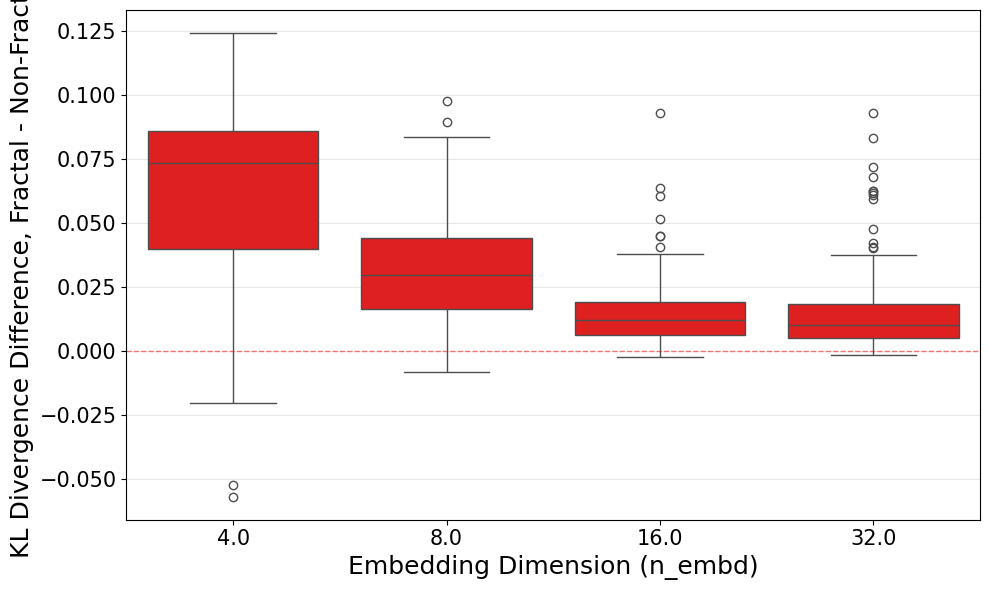

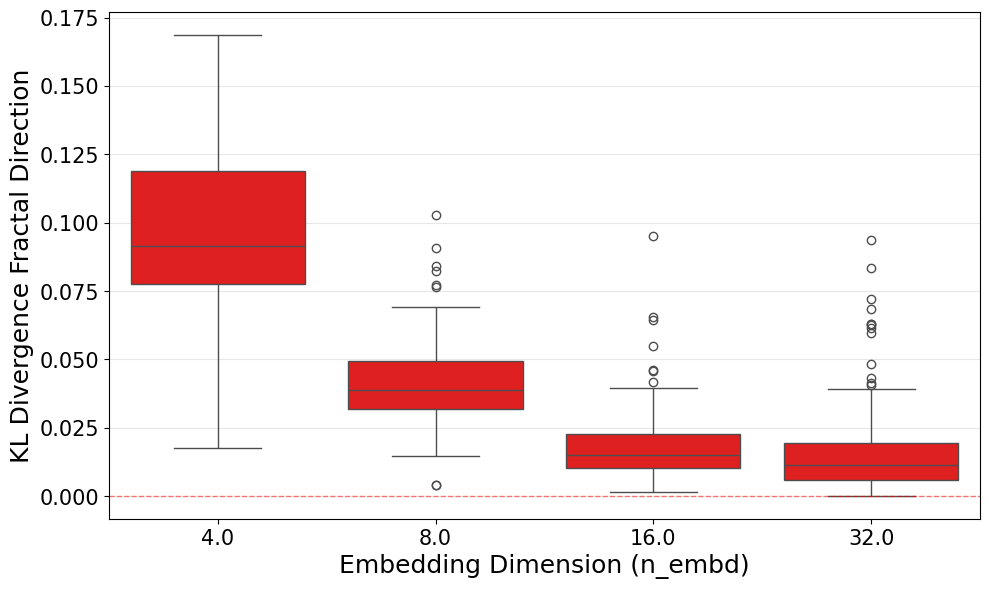

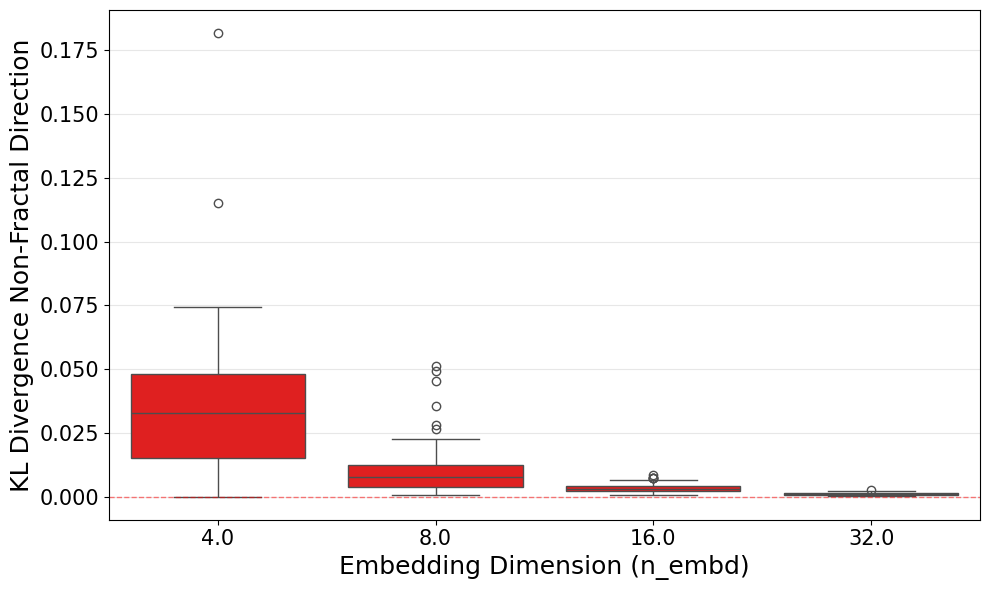

In [81]:
import seaborn as sns

def plot_violin(x_key, y_key, x_label="Embedding Dimension (n_embd)", y_label="KL Divergence Difference, Fractal - Non-Fractal"):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Prepare data for violin plot - filter to only show 4, 8, 16, 32
    df_plot = df_filtered[['n_embd', 'kl_para', 'kl_orth']].copy()
    df_plot['kl_diff'] = df_plot['kl_para'] - df_plot['kl_orth']
    df_plot = df_plot[df_plot['n_embd'].isin([4, 8, 16, 32])]

    # Create violin plot with increased font size
    sns.boxplot(data=df_plot, x=x_key, y=y_key, ax=ax, color='red')

    ax.set_xlabel(x_label, fontsize=18)
    ax.set_ylabel(y_label, fontsize=18)
    # ax.set_ylim(-1e-2, 0.1)
    # ax.set_title('Distribution of KL Divergence for ablating fractal directions by Embedding Dimension', fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='r', linestyle='--', linewidth=1, alpha=0.5)

    plt.tight_layout()
    plt.show()

plot_violin('n_embd', 'kl_diff', y_label='KL Divergence Difference, Fractal - Non-Fractal')
plot_violin('n_embd', 'kl_para', y_label='KL Divergence Fractal Direction')
plot_violin('n_embd', 'kl_orth', y_label='KL Divergence Non-Fractal Direction')

In [97]:
# DIAGNOSTIC: Check what's actually in the saved data
sample_idx = 10
sample_stats = df_filtered.iloc[sample_idx]['abl_stats']
sample_n_embd = df_filtered.iloc[sample_idx]['n_embd']

print(f"Model {sample_idx}:")
print(f"  n_embd: {sample_n_embd}")
print(f"  abl_stats shape: {sample_stats.shape}")
print(f"  Min value in entire array: {sample_stats.min():.6f}")
print(f"  Max value in entire array: {sample_stats.max():.6f}")
print(f"  Any negative values? {(sample_stats < 0).any()}")
print(f"\nMean by direction slices:")
print(f"  [:, :2, :].mean(): {sample_stats[:, :2, :].mean():.6f}")
print(f"  [:, 2:-4, :].mean(): {sample_stats[:, 2:-4, :].mean():.6f}")
print(f"  [:, -4:, :].mean(): {sample_stats[:, -4:, :].mean():.6f}")

# Check a few individual values
print(f"\nSample individual KL values:")
print(f"  Layer 0, Direction 0: min={sample_stats[0, 0, :].min():.6f}, max={sample_stats[0, 0, :].max():.6f}, mean={sample_stats[0, 0, :].mean():.6f}")
print(f"  Layer 0, Direction 1: min={sample_stats[0, 1, :].min():.6f}, max={sample_stats[0, 1, :].max():.6f}, mean={sample_stats[0, 1, :].mean():.6f}")

Model 10:
  n_embd: 32.0
  abl_stats shape: (3, 36, 1000)
  Min value in entire array: -0.000000
  Max value in entire array: 0.328769
  Any negative values? True

Mean by direction slices:
  [:, :2, :].mean(): 0.021435
  [:, 2:-4, :].mean(): 0.000734
  [:, -4:, :].mean(): 0.000693

Sample individual KL values:
  Layer 0, Direction 0: min=0.000000, max=0.002829, mean=0.000244
  Layer 0, Direction 1: min=-0.000000, max=0.017732, mean=0.001792


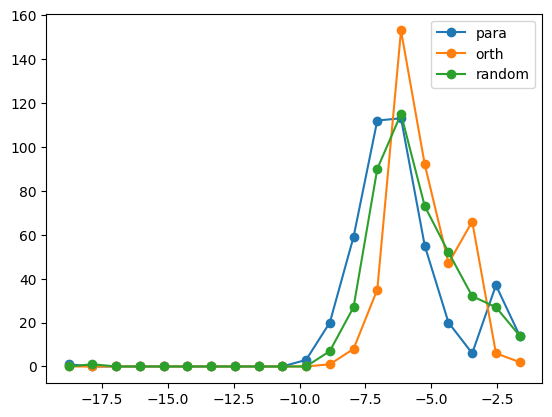

In [41]:
kl_para_arr = np.log(np.array(kl_para))
kl_orth_arr = np.log(np.array(kl_orth))
kl_random_arr = np.log(np.array(kl_random))

# kl_para_arr = kl_para_arr[kl_para_arr < 0.1]
# kl_orth_arr = kl_orth_arr[kl_orth_arr < 0.1]
# kl_random_arr = kl_random_arr[kl_random_arr < 0.1]

counts_para, bin_edges = np.histogram(kl_para_arr, bins=20)
counts_orth, _ = np.histogram(kl_orth_arr, bins=bin_edges)
counts_random, _ = np.histogram(kl_random_arr, bins=bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.plot(bin_centers, counts_para, 'o-', label='para')
plt.plot(bin_centers, counts_orth, 'o-', label='orth')
plt.plot(bin_centers, counts_random, 'o-', label='random')


plt.legend()

In [27]:
kl_orth

[np.float32(0.00035534226),
 np.float32(0.004299984),
 np.float32(0.0010647281),
 np.float32(0.00085106975),
 np.float32(0.00017590531),
 np.float32(0.000511572),
 np.float32(0.0002686342),
 np.float32(0.0009087548),
 np.float32(0.00041306546),
 np.float32(0.0009831707),
 np.float32(0.0011756773),
 np.float32(0.0013630134),
 np.float32(0.0011110344),
 np.float32(0.00090730016),
 np.float32(0.01222291),
 np.float32(0.001266684),
 np.float32(0.00043735767),
 np.float32(0.0008479488),
 np.float32(0.0024779406),
 np.float32(0.0039035787),
 np.float32(0.0030126749),
 np.float32(0.0019221387),
 np.float32(0.0018333788),
 np.float32(0.00054839364),
 np.float32(0.0014249285),
 np.float32(0.0012327614),
 np.float32(0.009645782),
 np.float32(0.0013078349),
 np.float32(0.00041622846),
 np.float32(0.00070289586),
 np.float32(0.001964086),
 np.float32(0.00052237767),
 np.float32(0.001628911),
 np.float32(0.001249518),
 np.float32(0.0006864303),
 np.float32(0.0019234478),
 np.float32(0.0049515883),


In [28]:
kl_random

[np.float32(0.0006699986),
 np.float32(0.0024175118),
 np.float32(0.0012456836),
 np.float32(0.00090400485),
 np.float32(0.00068051886),
 np.float32(0.0013492369),
 np.float32(0.0010094842),
 np.float32(0.0020286534),
 np.float32(0.0010739298),
 np.float32(0.0009145654),
 np.float32(0.0021739681),
 np.float32(0.00056557055),
 np.float32(0.0014295629),
 np.float32(0.0016479541),
 np.float32(0.017244995),
 np.float32(0.0021032065),
 np.float32(0.000617698),
 np.float32(0.001653199),
 np.float32(0.0022866528),
 np.float32(0.003620506),
 np.float32(0.0022851503),
 np.float32(0.0015938454),
 np.float32(0.0013486106),
 np.float32(0.00048812944),
 np.float32(0.0019867814),
 np.float32(0.0013637422),
 np.float32(0.012175002),
 np.float32(0.0014719603),
 np.float32(0.0005138642),
 np.float32(0.0023325277),
 np.float32(0.0023618524),
 np.float32(0.0012250709),
 np.float32(0.0016997088),
 np.float32(0.0018847123),
 np.float32(0.001557361),
 np.float32(0.0019208753),
 np.float32(0.014274989),
 np.

# Activation Patching